# Week 4: Classification with Naive Bayes
## News headline classification practical

Use a headline to predict the class recorded in the supplied dataset. You will construct word counts, train a Naive Bayes classifier, compare it with a baseline, and evaluate predictions on held-out data.

Run the cells in order. Keep `news_dataset.csv` in your working directory. In VS Code, select the Python environment that contains the required packages as your notebook kernel.

If packages are missing, install the packages listed in `requirements.txt` in that environment. The supplied notebook contains a complete worked example; change the practice inputs to check your understanding.

**Dataset labels:** this file uses `0` and `1`. We retain those names because the original label definition has not been supplied. Do not rename the classes “fake” and “real” until the dataset documentation confirms their meanings. A headline classifier learns patterns associated with these labels; it does not independently verify a news claim.


## 1. Import the tools

`pandas` handles tables. `CountVectorizer` turns text into word counts. `MultinomialNB` learns the classification rule. A `Pipeline` keeps text processing and the classifier together.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)


## 2. Calculate a posterior probability by hand

This is an **invented teaching example**, separate from the news CSV.

Among 100 headlines, 40 belong to Class 0 and 60 to Class 1. The word “shocking” appears in 30 Class 0 headlines and 10 Class 1 headlines.

1. Calculate the prior probability of Class 0.
2. Calculate the probability of seeing “shocking” within each class.
3. Calculate the probability of Class 0 given that “shocking” appears.

$$P(C_0\mid S)=\frac{P(S\mid C_0)P(C_0)}{P(S\mid C_0)P(C_0)+P(S\mid C_1)P(C_1)}$$

Here, $C_0$ means Class 0 and $S$ means that “shocking” appears. The denominator adds the probability of observing the word through either class.


In [2]:
prior_0, prior_1 = 40 / 100, 60 / 100
likelihood_0, likelihood_1 = 30 / 40, 10 / 60

joint_0 = likelihood_0 * prior_0
joint_1 = likelihood_1 * prior_1
posterior_0 = joint_0 / (joint_0 + joint_1)

print(f"P(Class 0) = {prior_0:.2f}")
print(f"P(shocking | Class 0) = {likelihood_0:.2f}")
print(f"P(shocking | Class 1) = {likelihood_1:.4f}")
print(f"P(Class 0 | shocking) = {posterior_0:.2f}")


P(Class 0) = 0.40
P(shocking | Class 0) = 0.75
P(shocking | Class 1) = 0.1667
P(Class 0 | shocking) = 0.75


## 3. Turn a small set of headlines into word counts

The following four headlines form a **second invented teaching corpus**. Their class totals differ from the previous 100-headline example.

1. Count how often each word appears in each headline.
2. Check your counts against the table printed below.
3. Notice that the last headline contains “report” twice. Multinomial Naive Bayes uses these counts.

`fit_transform` learns the vocabulary and creates the count matrix. A vocabulary column has the same meaning for every row.


In [3]:
toy_headlines = [
    "shocking market claim",
    "shocking claim",
    "market report",
    "market report report"
]
toy_labels = np.array([0, 0, 1, 1])

toy_vectorizer = CountVectorizer()
toy_counts = toy_vectorizer.fit_transform(toy_headlines)
toy_words = toy_vectorizer.get_feature_names_out()

count_table = pd.DataFrame(
    toy_counts.toarray(), columns=toy_words, index=toy_headlines
)
print(count_table.to_string())


                       claim  market  report  shocking
shocking market claim      1       1       0         1
shocking claim             1       0       0         1
market report              0       1       1         0
market report report       0       1       2         0


### Apply smoothing and combine the word evidence

For word $w$ and class $c$, the smoothed word probability is

$$\theta_{wc}=\frac{N_{wc}+\alpha}{N_c+\alpha V}.$$

$N_{wc}$ counts occurrences of the word in that class. $N_c$ counts all word occurrences in that class, and $V$ is the vocabulary size. With $\alpha=1$, a word absent from one class receives a small positive probability.

For the new headline “shocking report”, both words occur once:

$$s_c=P(c)\,\theta_{\text{shocking},c}\,\theta_{\text{report},c},\qquad
P(c\mid\text{headline})=\frac{s_c}{s_0+s_1}.$$

The conditional independence assumption lets us multiply the word probabilities **within each class**. It is an approximation to how language works.


In [4]:
toy_model = MultinomialNB(alpha=1.0)
toy_model.fit(toy_counts, toy_labels)

word_counts_by_class = pd.DataFrame(
    toy_model.feature_count_.astype(int),
    index=["Class 0", "Class 1"], columns=toy_words
)
word_probabilities = pd.DataFrame(
    np.exp(toy_model.feature_log_prob_),
    index=["Class 0", "Class 1"], columns=toy_words
)

new_toy_counts = toy_vectorizer.transform(["shocking report"])
toy_posterior = toy_model.predict_proba(new_toy_counts)[0]

print("Word counts within each class:")
print(word_counts_by_class.to_string())
print("\nSmoothed word probabilities:")
print(word_probabilities.round(4).to_string())
print("\nModel probability for 'shocking report':")
for label, probability in zip(toy_model.classes_, toy_posterior):
    print(f"Class {label}: {probability:.4f}")
print("Predicted class:", toy_model.predict(new_toy_counts)[0])


Word counts within each class:
         claim  market  report  shocking
Class 0      2       1       0         2
Class 1      0       2       3         0

Smoothed word probabilities:
          claim  market  report  shocking
Class 0  0.3333  0.2222  0.1111    0.3333
Class 1  0.1111  0.3333  0.4444    0.1111

Model probability for 'shocking report':
Class 0: 0.4286
Class 1: 0.5714
Predicted class: 1


**Check:** both classes have five word occurrences and the vocabulary has four words. The scores are `0.5 × (3/9) × (1/9)` for Class 0 and `0.5 × (1/9) × (4/9)` for Class 1. Normalizing gives `3/7` and `4/7`.

The model selects Class 1. These are model probabilities under its assumptions; they need not match real-world frequencies exactly.

**Try it:** change the new headline to “shocking claim” and explain which class you expect before running the prediction.


## 4. Read and inspect the supplied news dataset

Each row contains a title, article body, subject, date, and class label. The practical uses **only the title as the input**. The target is `label`.

The file is read from the current working directory. The alternate filename is supported for copies downloaded as `news_dataset(1).csv`.


In [5]:
csv_path = Path("news_dataset.csv")
if not csv_path.exists():
    csv_path = Path("news_dataset(1).csv")

raw = pd.read_csv(csv_path)
print("Shape:", raw.shape)
print("Columns:", raw.columns.tolist())
print("\nClass counts:")
print(raw["label"].value_counts().sort_index().to_string())
print("\nMissing values:")
print(raw.isna().sum().to_string())
assert set(raw["label"].unique()) == {0, 1}


Shape: (6000, 5)
Columns: ['title', 'text', 'subject', 'date', 'label']

Class counts:
label
0    3000
1    3000

Missing values:
title      0
text       0
subject    0
date       0
label      0


### Check for a shortcut in the data

The table below counts labels within each subject. A subject occurring in only one class can become an easy shortcut. A high score based on that shortcut would not show that the model understands factual accuracy.

We exclude `subject`, `date`, and the article body from the model inputs. Headline wording can still contain source or style cues, so held-out performance has a limited interpretation.


In [6]:
print(pd.crosstab(raw["subject"], raw["label"]).to_string())


label               0     1
subject                    
Government News   185     0
Middle-east       100     0
News             1175     0
US_News            97     0
left-news         573     0
politics          870     0
politicsNews        0  1564
worldnews           0  1436


## 5. Remove repeated examples before splitting

Repeated headlines or article bodies can make a held-out set too similar to training data.

1. Normalize text for duplicate checks by ignoring capitalization and extra spaces.
2. Remove empty titles and repeated normalized titles.
3. Remove repeated nonempty normalized bodies. Blank bodies are retained because the model uses titles.

These rules use text only; they do not learn a predictive vocabulary from the full dataset. They prevent exact duplicate overlap, but they do not remove every paraphrase or related story.


In [7]:
news = raw.copy()
news["title"] = news["title"].fillna("").astype(str)
news["text"] = news["text"].fillna("").astype(str)

news["title_key"] = (
    news["title"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)
news["body_key"] = (
    news["text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)

news = news.loc[news["title_key"].ne("")].copy()
before_title = len(news)
news = news.drop_duplicates("title_key", keep="first").copy()
removed_titles = before_title - len(news)

repeated_body = news["body_key"].ne("") & news["body_key"].duplicated()
removed_bodies = int(repeated_body.sum())
news = news.loc[~repeated_body].copy()

print("Repeated titles removed:", removed_titles)
print("Additional repeated bodies removed:", removed_bodies)
print("Rows retained:", len(news))
print("Class counts after cleaning:")
print(news["label"].value_counts().sort_index().to_string())


Repeated titles removed: 116
Additional repeated bodies removed: 1
Rows retained: 5883
Class counts after cleaning:
label
0    2896
1    2987


## 6. Create training, validation, and final test sets

Use approximately 60% for training, 20% for validation, and 20% for the final test. `stratify` keeps class proportions similar across the sets. `random_state=42` makes the split reproducible.

- **Training:** learn the vocabulary, class priors, and word probabilities.
- **Validation:** compare the baseline and smoothing settings.
- **Final test:** evaluate the selected model after the settings are fixed.

This random split measures performance on similar articles from the same dataset. A system intended for future news would also need evaluation on later articles and new sources.


In [8]:
train, held_out = train_test_split(
    news, test_size=0.40, stratify=news["label"], random_state=42
)
valid, test = train_test_split(
    held_out, test_size=0.50, stratify=held_out["label"], random_state=42
)

split_counts = pd.DataFrame({
    "Training": train["label"].value_counts(),
    "Validation": valid["label"].value_counts(),
    "Final test": test["label"].value_counts()
}).sort_index()
split_counts.index.name = "Class"
print(split_counts.to_string())
print("\nRows:", len(train), len(valid), len(test))


       Training  Validation  Final test
Class                                  
0          1737         579         580
1          1792         598         597

Rows: 3529 1177 1177


## 7. Establish a majority-class baseline

The baseline always predicts the class most common in the training set. It gives a simple comparison for the learned model.

We will use **macro F1** to select a smoothing setting. Macro F1 averages the F1 score of the two classes, giving each class equal weight.


In [9]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(train[["title"]], train["label"])
baseline_valid = baseline.predict(valid[["title"]])

baseline_accuracy = accuracy_score(valid["label"], baseline_valid)
baseline_f1 = f1_score(valid["label"], baseline_valid, average="macro")
print("Baseline predicted class:", int(baseline_valid[0]))
print(f"Validation accuracy: {baseline_accuracy:.4f}")
print(f"Validation macro F1: {baseline_f1:.4f}")


Baseline predicted class: 1
Validation accuracy: 0.5081
Validation macro F1: 0.3369


## 8. Train Naive Bayes on headline word counts

The pipeline learns its vocabulary from training headlines only. It then uses the same vocabulary to transform validation headlines.

- `stop_words="english"` removes a fixed list of common English words.
- `min_df=2` keeps words that appear in at least two training headlines.
- `alpha=1.0` applies Laplace smoothing.

In the general model, a headline has count $x_w$ for each vocabulary word:

$$s_c=P(c)\prod_{w=1}^{V}\theta_{wc}^{x_w}.$$

The implementation works with logarithms to avoid multiplying many tiny numbers. `fit` learns the probabilities, and `predict` selects the class with the largest score.

This `alpha` controls **probability smoothing**. It has a different role from the Ridge regularization parameter studied in Week 3.


In [10]:
model = Pipeline([
    ("counts", CountVectorizer(stop_words="english", min_df=2)),
    ("nb", MultinomialNB(alpha=1.0))
])
model.fit(train["title"], train["label"])
valid_pred = model.predict(valid["title"])

vocabulary_size = len(model.named_steps["counts"].vocabulary_)
print("Training vocabulary size:", vocabulary_size)
print(f"Validation accuracy: {accuracy_score(valid['label'], valid_pred):.4f}")
print(f"Validation macro F1: {f1_score(valid['label'], valid_pred, average='macro'):.4f}")


Training vocabulary size: 3777
Validation accuracy: 0.9014
Validation macro F1: 0.9014


## 9. Read the classification metrics

In the printed confusion matrix, **rows are actual classes** and **columns are predicted classes**, both in the order `[0, 1]`.

For this calculation only, designate **Class 0 as the positive class**. Positive is an evaluation choice; it does not mean that a class is good or true.

$$\text{Accuracy}=\frac{TP+TN}{TP+FP+FN+TN},\quad
\text{Precision}=\frac{TP}{TP+FP},\quad
\text{Recall}=\frac{TP}{TP+FN}$$

$$F_1=\frac{2\times\text{Precision}\times\text{Recall}}{\text{Precision}+\text{Recall}}$$

1. Locate correct predictions on the diagonal.
2. Find the two kinds of mistakes off the diagonal.
3. Calculate Class 0 precision and recall, then compare them with the report.


In [11]:
valid_cm = confusion_matrix(valid["label"], valid_pred, labels=[0, 1])
print("Validation confusion matrix (rows actual, columns predicted):")
print(valid_cm)

tp, fn = valid_cm[0, 0], valid_cm[0, 1]
fp, tn = valid_cm[1, 0], valid_cm[1, 1]
print(f"\nClass 0 precision: {tp / (tp + fp):.4f}")
print(f"Class 0 recall: {tp / (tp + fn):.4f}")
print("\nValidation classification report:")
print(classification_report(
    valid["label"], valid_pred, labels=[0, 1],
    target_names=["Class 0", "Class 1"], digits=4, zero_division=0
))


Validation confusion matrix (rows actual, columns predicted):
[[518  61]
 [ 55 543]]

Class 0 precision: 0.9040
Class 0 recall: 0.8946

Validation classification report:
              precision    recall  f1-score   support

     Class 0     0.9040    0.8946    0.8993       579
     Class 1     0.8990    0.9080    0.9035       598

    accuracy                         0.9014      1177
   macro avg     0.9015    0.9013    0.9014      1177
weighted avg     0.9015    0.9014    0.9014      1177



### Inspect validation mistakes

Inspect these examples while developing the model. Compare the title, recorded class, and predicted class.

1. Choose one error in each direction.
2. Describe a possible reason using the information in the headline.
3. Identify what additional evidence a person would need to check the claim.

A model mistake is a disagreement with the dataset label. Without source documentation, the label itself should not be treated as independently verified evidence.


In [12]:
validation_results = valid[["title", "label"]].copy()
validation_results["prediction"] = valid_pred
validation_errors = validation_results.loc[
    validation_results["label"] != validation_results["prediction"]
]

# Show short examples from each recorded class.
for label in [0, 1]:
    example = validation_errors.loc[validation_errors["label"].eq(label)].copy()
    example["length"] = example["title"].str.len()
    example = example.sort_values(["length", "title"]).head(1)
    for row in example.itertuples():
        print(f"Actual Class {row.label}, predicted Class {row.prediction}")
        print(row.title.strip())
        print()


Actual Class 0, predicted Class 1
Homepage

Actual Class 1, predicted Class 0
Texas lawyer sues Cruz to challenge eligibility



## 10. Select smoothing using validation data

Compare `alpha` values of `0.1`, `1.0`, and `10.0`. Each candidate is trained on the same training data. Choose the highest validation macro F1; if there is an exact tie, choose the smaller alpha.

The final test set is not used to choose the setting. After selection, retain the selected fitted pipeline without refitting it. This makes the validation and final test results refer to the same fitted model.


In [13]:
models = {1.0: model}
comparison_rows = []

for alpha in [0.1, 1.0, 10.0]:
    if alpha not in models:
        candidate = Pipeline([
            ("counts", CountVectorizer(stop_words="english", min_df=2)),
            ("nb", MultinomialNB(alpha=alpha))
        ])
        candidate.fit(train["title"], train["label"])
        models[alpha] = candidate

    prediction = models[alpha].predict(valid["title"])
    comparison_rows.append({
        "alpha": alpha,
        "accuracy": accuracy_score(valid["label"], prediction),
        "macro_f1": f1_score(valid["label"], prediction, average="macro")
    })

comparison = pd.DataFrame(comparison_rows).sort_values(
    ["macro_f1", "alpha"], ascending=[False, True]
)
best_alpha = float(comparison.iloc[0]["alpha"])
final_model = models[best_alpha]
print(comparison.round(4).to_string(index=False))
print("\nSelected alpha:", best_alpha)


 alpha  accuracy  macro_f1
   0.1    0.9091    0.9091
   1.0    0.9014    0.9014
  10.0    0.8845    0.8844

Selected alpha: 0.1


## 11. Evaluate the fixed model on the final test set

Evaluate the selected model and the baseline on the same final test rows. Do not change the vocabulary, features, alpha, or model after reviewing these results and then reuse this test score as an independent evaluation. Further development needs a new independent evaluation.

The table reports performance on this dataset split, not a guarantee for unfamiliar publishers, events, languages, or future news.


In [14]:
test_pred = final_model.predict(test["title"])
baseline_test = baseline.predict(test[["title"]])

final_rows = []
for name, prediction in [
    ("Majority baseline", baseline_test),
    (f"Naive Bayes (alpha={best_alpha:g})", test_pred)
]:
    final_rows.append({
        "model": name,
        "accuracy": accuracy_score(test["label"], prediction),
        "macro_f1": f1_score(test["label"], prediction, average="macro")
    })

final_comparison = pd.DataFrame(final_rows)
print(final_comparison.round(4).to_string(index=False))
print("\nFinal test classification report:")
print(classification_report(
    test["label"], test_pred, labels=[0, 1],
    target_names=["Class 0", "Class 1"], digits=4, zero_division=0
))


                  model  accuracy  macro_f1
      Majority baseline    0.5072    0.3365
Naive Bayes (alpha=0.1)    0.9023    0.9023

Final test classification report:
              precision    recall  f1-score   support

     Class 0     0.8869    0.9190    0.9026       580
     Class 1     0.9184    0.8861    0.9020       597

    accuracy                         0.9023      1177
   macro avg     0.9026    0.9025    0.9023      1177
weighted avg     0.9029    0.9023    0.9023      1177



Final test confusion matrix (rows actual, columns predicted):
[[533  47]
 [ 68 529]]


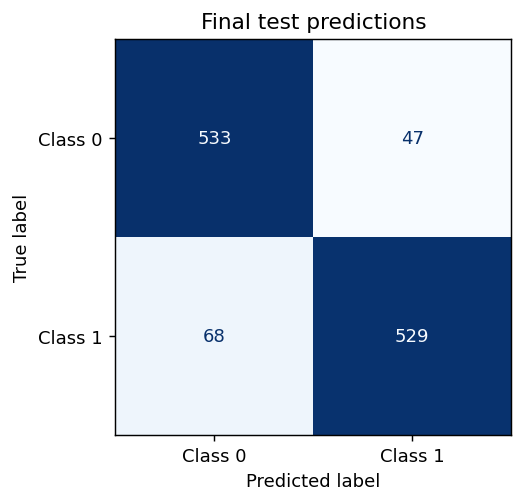

In [15]:
test_cm = confusion_matrix(test["label"], test_pred, labels=[0, 1])
print("Final test confusion matrix (rows actual, columns predicted):")
print(test_cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=test_cm, display_labels=["Class 0", "Class 1"]
).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Final test predictions")
plt.tight_layout()
plt.show()


## 12. Predict an unfamiliar headline

These are invented input examples. Their true labels are not supplied, so we can demonstrate predictions but cannot calculate their accuracy.

The model returns one probability for each class in `classes_` order. A high model probability can still be wrong, especially for unfamiliar writing or sources. Words absent from the learned vocabulary are ignored.


In [16]:
new_headlines = pd.Series([
    "City council approves new public library funding",
    "Scientists publish findings from a water quality study"
], name="title")

new_predictions = final_model.predict(new_headlines)
new_probabilities = final_model.predict_proba(new_headlines)
classes = final_model.named_steps["nb"].classes_

new_results = pd.DataFrame({
    "title": new_headlines,
    "prediction": new_predictions
})
for column, label in enumerate(classes):
    new_results[f"P(Class {label})"] = new_probabilities[:, column]

print(new_results.round(4).to_string(index=False))


                                                 title  prediction  P(Class 0)  P(Class 1)
      City council approves new public library funding           1      0.0640      0.9360
Scientists publish findings from a water quality study           0      0.7055      0.2945


## 13. Interpret the result

Use the printed results to answer the following questions.

1. How much did Naive Bayes improve on the majority baseline in final test accuracy and macro F1?
2. What does Class 0 precision tell you? What does Class 0 recall tell you?
3. Which alpha was selected, and which data was used to select it?
4. Why was `subject` excluded? What shortcuts might remain in headlines?
5. What would you need to check before using the classifier for newly published news?

**Written conclusion:** state the prediction task, the selected model, one final test result, and one limitation. Use the recorded class names accurately.

## References

- Course dataset: supplied `news_dataset.csv`, 6,000 rows. The original dataset URL and label definitions have not been provided; numerical labels are preserved.
- [scikit-learn: Naive Bayes and Multinomial Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html#multinomial-naive-bayes)
- [scikit-learn: CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)
- [scikit-learn: Classification metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)
